<a href="https://colab.research.google.com/github/hyunkoome/DL_Study/blob/dev/DL_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Feb  3 02:08:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc -V

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [3]:
!pip3 install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## **1. pytorch tensor 기본 연산**

In [4]:
import torch

In [9]:
x = torch.tensor([[1,0], [0, 1]], dtype=torch.float32)
y = torch.tensor([[5,6], [7, 8]], dtype=torch.float32)

# basic op
print(x+y)
print(x-y)
print(x * y) # multiple: element-wise
print(x @ y) # multiple

tensor([[6., 6.],
        [7., 9.]])
tensor([[-4., -6.],
        [-7., -7.]])
tensor([[5., 0.],
        [0., 8.]])
tensor([[5., 6.],
        [7., 8.]])


**ex01) 랜덤한 텐서 (3, 3)을 생성하고, 정규화를 수행하는 코드를 작성해 봐.**

In [16]:
import torch
import numpy as np

# create random tensor
random_tensor = torch.rand(3, 3, dtype=torch.float32)
print(random_tensor)

# min-max normalization
min_val = random_tensor.min()
max_val = random_tensor.max()
normalized_tensor = (random_tensor-min_val)/(max_val-min_val)
print(normalized_tensor)

tensor([[0.7960, 0.9164, 0.5767],
        [0.0654, 0.5653, 0.2052],
        [0.4380, 0.4607, 0.7325]])
tensor([[0.8586, 1.0000, 0.6008],
        [0.0000, 0.5875, 0.1643],
        [0.4379, 0.4645, 0.7839]])


## **2. pytorch Autograd 자동 미분**

In [17]:
# requres_grad=True 설정 시, 자동 미분

a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

y = a**2 + b**3
y.backward()

print(a.grad) # dy/da
print(b.grad) # dy/db

tensor(4.)
tensor(27.)


**ex02) f(x) = x^3 + 2x^2 + 5x + 1 의 도함수를 자동 미분으로 구해보자.**

In [19]:
import torch
import numpy as np

x = torch.tensor(2.0, requires_grad=True)

f_x = x**3 + 2*x**2 + 5*x + 1
f_x.backward()

print(f"f'(x) at x=2: {x.grad}") # d f_x /dx

f'(x) at x=2: 25.0


## **3. pytorch 간단한 신경망 MLP 구현**

In [21]:
import torch.nn as nn
import torch.optim as optim

# simple mlp
class SimpleMLP(nn.Module):
  def __init__ (self, input_size, hidden_size, output_size):
    super(SimpleMLP, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x


# create model
model = SimpleMLP(input_size=10, hidden_size=20, output_size=1)
print(model)

SimpleMLP(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)


**ex03) 입력 차원이 5이고 출력이 2인 다층 퍼셉트론(MLP) 을 직접 만들어 보고 forward-pass를 실행해 봐**

In [28]:
import torch.nn as nn
import torch.optim as optim

# simple MLP
class MyMLP(nn.Module):
  def __init__(self, input=5, hidden=10, output=2):
    super(MyMLP, self).__init__()

    self.fc1 = nn.Linear(input, hidden)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden, output)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

# create model
my_model = MyMLP()
my_model.eval()
print(my_model)

# create random data, batch 1, input 5
input_data = torch.rand(1, 5, dtype=torch.float32)
print(f"input_data: {input_data}")

# run forward-pass
out_put = my_model(input_data)

# print
print(f"MLP forward-pass: {out_put}")

MyMLP(
  (fc1): Linear(in_features=5, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=2, bias=True)
)
input_data: tensor([[0.0203, 0.0835, 0.7752, 0.7813, 0.6338]])
MLP forward-pass: tensor([[-0.2510,  0.3278]], grad_fn=<AddmmBackward0>)


## **4. PyTorch로 간단한 선형 회귀 모델 학습**


100개의 랜덤한 데이터를 사용하여 다음과 같은 선형 모델을 학습하려고 한다.

y = 2x + 3

- PyTorch를 사용하여 x_train과 y_train 데이터를 생성하시오.
- 위에서 생성한 데이터를 이용하여 PyTorch의 nn.Linear를 사용하여 선형 회귀 모델을 정의하시오.
- 또한, 손실 함수로 nn.MSELoss()를 설정하시오.
- 학습률(learning rate)이 0.1인 SGD(Stochastic Gradient Descent) 옵티마이저를 설정하시오.
- 에포크(epoch)를 100으로 설정하고, 모델을 학습하는 코드를 작성하고, 10 에포크마다 손실(loss)을 출력하시오.
- 학습이 완료된 후, model.parameters()를 이용하여 학습된 가중치(weight)와 편향(bias)을 출력하시오.
출력된 값이 실제 수식 y = 2x + 3 과 유사한지 확인하시오.

예제 출력 예시
```
Epoch 0: Loss = 4.531
Epoch 10: Loss = 0.312
Epoch 20: Loss = 0.058
...
Epoch 90: Loss = 0.004
Learned Parameters: [tensor(1.98), tensor(3.01)]
```



In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 랜덤한 데이터 생성 (y = 2x + 3)
torch.manual_seed(42)  # 랜덤 시드 고정 (재현성)
x_train = torch.randn(100, 1)  # 100개의 랜덤한 x 값
y_train = 2 * x_train + 3 # + 0.1 * torch.randn(100, 1)  # 노이즈 추가

# 2. 선형 회귀 모델 정의
model = nn.Linear(1, 1)  # 입력 차원 1, 출력 차원 1

# 3. 손실 함수 및 옵티마이저 설정
loss_fn = nn.MSELoss()  # 평균제곱오차(MSE) 손실 함수
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 학습률 0.1, SGD 옵티마이저

# 4. 모델 학습
epochs = 100
for epoch in range(epochs):
    # 예측값 계산 (Forward-pass)
    y_pred = model(x_train)

    # 손실 계산
    loss = loss_fn(y_pred, y_train)

    # 기울기 초기화 후 역전파(Backward-pass) 및 가중치 업데이트
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 10 에포크마다 손실 출력
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 19.1948
Epoch 10: Loss = 0.1817
Epoch 20: Loss = 0.0018
Epoch 30: Loss = 0.0000
Epoch 40: Loss = 0.0000
Epoch 50: Loss = 0.0000
Epoch 60: Loss = 0.0000
Epoch 70: Loss = 0.0000
Epoch 80: Loss = 0.0000
Epoch 90: Loss = 0.0000


In [32]:
# 5. 학습된 가중치와 편향 출력
w, b = list(model.parameters())
print(f"\nLearned Weight: {w.item():.4f}")  # 학습된 가중치
print(f"Learned Bias: {b.item():.4f}")  # 학습된 편향


Learned Weight: 2.0000
Learned Bias: 3.0000


**ex04) y = 3x^2 + 2x + 1 형태의 비선형 회귀 모델을 MLP로 구현해보고 학습해 봐.**

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
# data
x_train = torch.rand(100, 1, dtype=torch.float32)
y_train = 3 * x_train**2 + 2*x_train + 1

# define Model
class myLiearModel(nn.Module):
  def __init__(self, input=1, hidden=10, output=1):
    super(myLiearModel, self).__init__()

    self.fc1 = nn.Linear(input, hidden)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden, output)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

myModel = myLiearModel()

# define loss, optimizer
loss_fn = nn.MSELoss()
optimiser = optim.SGD(params=myModel.parameters(), lr=0.1)

In [39]:
# train
train_epoches = 10000
for ep in range(train_epoches):
  y_pred = myModel(x_train)

  loss = loss_fn(y_pred, y_train)

  optimiser.zero_grad()
  loss.backward()
  optimiser.step()

  if ep % 1000 == 0:
    print(f"Epoch ({ep}): loss = {loss.item():.4f} ")


Epoch (0): loss = 0.0042 
Epoch (1000): loss = 0.0022 
Epoch (2000): loss = 0.0022 
Epoch (3000): loss = 0.0022 
Epoch (4000): loss = 0.0022 
Epoch (5000): loss = 0.0022 
Epoch (6000): loss = 0.0022 
Epoch (7000): loss = 0.0022 
Epoch (8000): loss = 0.0022 
Epoch (9000): loss = 0.0022 


In [47]:
# train results

"""
torch.linspace(start, end, steps)
* torch.linspace(-2, 2, 100): -2에서 2까지 균등한 간격으로 100개의 숫자를 생성,
* 즉, x_test 값은 -2, -1.96, -1.92, ..., 1.96, 2.0 이런 식으로 100개의 값이 생성

.reshape(-1, 1)
* .reshape(-1, 1)은 텐서의 차원을 변형하는 함수야.
* -1을 사용하면 PyTorch가 자동으로 적절한 크기를 맞춤.
* (100,) 형태의 1D 텐서를 (100,1) 형태의 2D 텐서로 변환.
"""
x_text = torch.linspace(-2, 2, 100).reshape(-1, 1)  # -2~2까지 균등간격의 100개 데이터 생성해서, 100x1 텐서 생성

y_test_pred = myModel(x_text).detach().numpy()

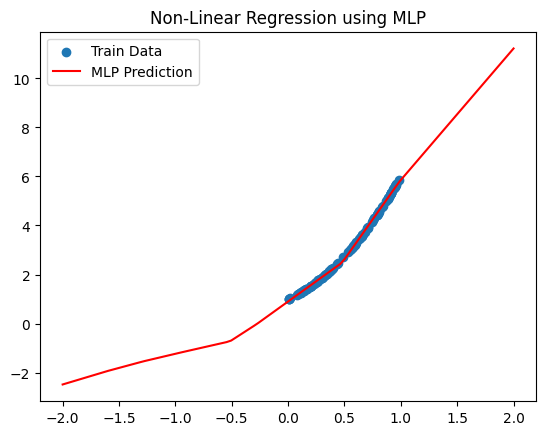

In [46]:
# 6. 예측 결과 시각화
import matplotlib.pyplot as plt

plt.scatter(x_train.numpy(), y_train.numpy(), label="Train Data")
plt.plot(x_text.numpy(), y_test_pred, color="red", label="MLP Prediction")
plt.legend()
plt.title("Non-Linear Regression using MLP")
plt.show()